In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("Fish.csv")
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [4]:
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [ ]:
# simple linear regression

In [5]:
df.isna().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

<Axes: >

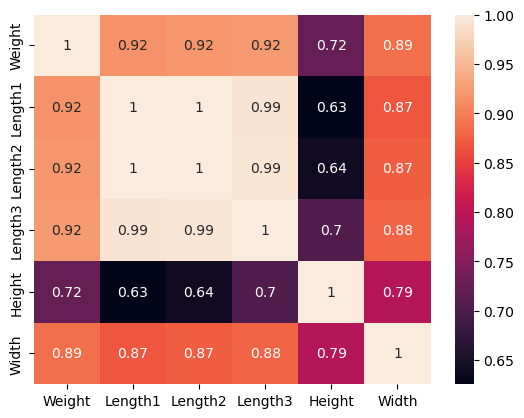

In [7]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: xlabel='Length1', ylabel='Weight'>

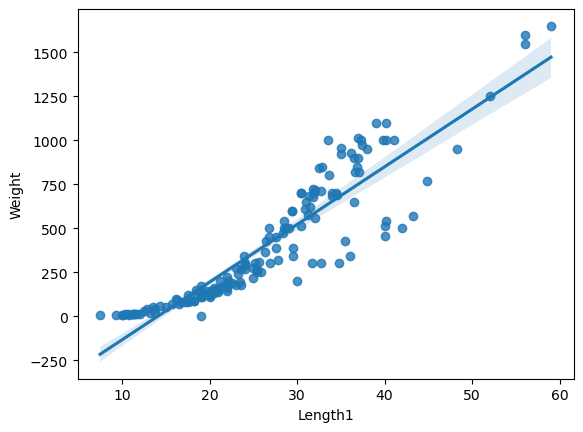

In [8]:
sns.regplot(data=df,x="Length1",y="Weight")

In [ ]:
# for predicting weight from length1

In [9]:
x=df[['Length1']]
y=df[['Weight']]

In [10]:
x,y

(     Length1
 0       23.2
 1       24.0
 2       23.9
 3       26.3
 4       26.5
 ..       ...
 154     11.5
 155     11.7
 156     12.1
 157     13.2
 158     13.8
 
 [159 rows x 1 columns],
      Weight
 0     242.0
 1     290.0
 2     340.0
 3     363.0
 4     430.0
 ..      ...
 154    12.2
 155    13.4
 156    12.2
 157    19.7
 158    19.9
 
 [159 rows x 1 columns])

In [ ]:
# split in two part train and test

In [16]:
from sklearn.model_selection import train_test_split

In [18]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42)

In [20]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(106, 1)
(53, 1)
(106, 1)
(53, 1)


In [ ]:
# Build a model

In [22]:
from sklearn.linear_model import LinearRegression

In [23]:
model=LinearRegression()

In [24]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
model.coef_

array([[33.3693826]])

In [26]:
model.intercept_

array([-483.23082018])

In [29]:
y_pred=model.predict(x_test)

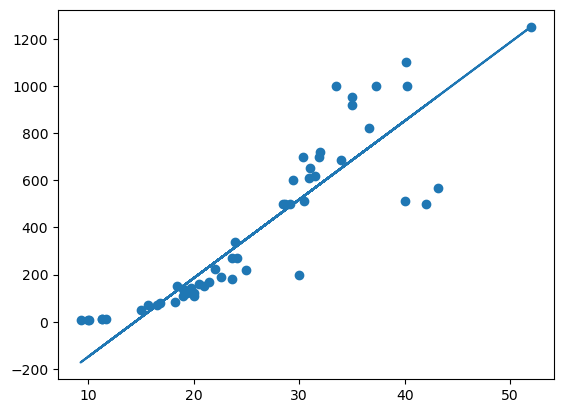

In [30]:
plt.plot(x_test,y_pred)
plt.scatter(x_test,y_test)
plt.show()

In [32]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [33]:
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

109.63894260403706
23320.121126584265
0.7991913425565906


In [34]:
model.predict(np.array([[25]]))


C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[351.00374487]])

In [43]:
x1=df.drop(['Species','Weight'],axis=1)
y1=df[['Weight']]
x1_train, x1_test, y1_train, y1_test = train_test_split(x1, y1, test_size=0.33, random_state=42)
model=LinearRegression()
model.fit(x1_train,y1_train)
y_pred=model.predict(x_test)






(106, 5)
(53, 5)
(106, 1)
(53, 1)


In [47]:
df=pd.read_csv("Fish.csv")
x=df.drop(['Species','Weight'],axis=1)
y=df[["Weight"]]
test=[0.75,0.8,0.85,0.9,0.95]
mse=[]
r2=[]
for i in test:
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=i, random_state=40)
    model=LinearRegression()
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    mse.append(mean_squared_error(y_test,y_pred))
    r2.append(r2_score(y_test,y_pred))
    
    


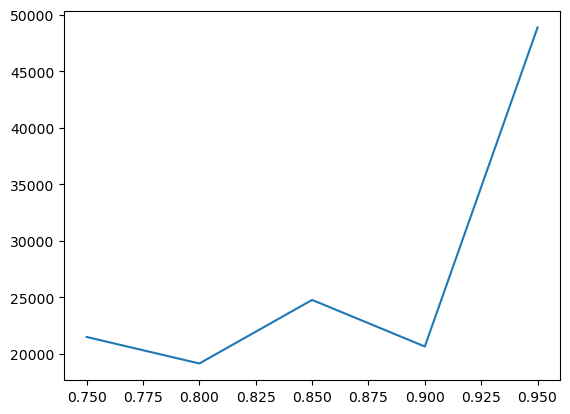

In [48]:
plt.plot(test,mse)

In [51]:
df=pd.read_csv("Ice_cream selling data.csv")
df

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531
5,-3.455712,30.001138
6,-3.108440,22.635401
7,-3.081303,25.365022
8,-2.672461,19.226970
9,-2.652287,20.279679


In [53]:
x=df[['Temperature (°C)']]
y=df[['Ice Cream Sales (units)']]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42)
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

9.975663768388085
120.0443699672773
0.03300924089591284


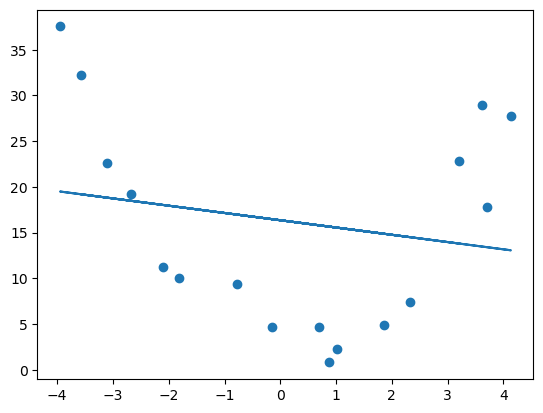

In [56]:
plt.plot(x_test,y_pred)
plt.scatter(x_test,y_test)
plt.show()